In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Data/news_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

Dataset shape: (6000, 5)
                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  
Index(['title', 'text', '

In [4]:
df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("") + " " +
    df["subject"].fillna("")
)

print(df["combined_text"].head())

0     WATCH: Trump Just Told All The Anti-Gay Bigot...
1    China backs U.N. call for justice in Yemen, U....
2    THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...
3    WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...
4    Lawmakers aim to delay U.S. ceding control of ...
Name: combined_text, dtype: str


In [5]:
import re
from nltk.corpus import stopwords

# If needed, run once:
# import nltk
# nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()
    
    # Keep only alphabetic characters
    words = re.findall(r"\b[a-z]{3,}\b", text)
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    return words

df["tokens"] = df["combined_text"].apply(preprocess_text)

print(df["tokens"].head())

0    [watch, trump, told, anti, gay, bigots, mike, ...
1    [china, backs, call, justice, yemen, saudis, g...
2    [people, president, trump, meets, coal, worker...
3    [wsj, reporter, rips, dem, candidates, lame, r...
4    [lawmakers, aim, delay, ceding, control, inter...
Name: tokens, dtype: object


In [6]:
transactions = df["tokens"].tolist()

print("Number of transactions:", len(transactions))
print("First transaction:")
print(transactions[0][:30])

Number of transactions: 6000
First transaction:
['watch', 'trump', 'told', 'anti', 'gay', 'bigots', 'mike', 'pence', 'whole', 'lot', 'evangelical', 'trump', 'voters', 'discovered', 'got', 'duped', 'picking', 'mike', 'pence', 'vice', 'president', 'donald', 'trump', 'sent', 'message', 'lgbt', 'community', 'rights', 'jeopardy', 'rolled']


In [7]:
from collections import Counter

word_counts = Counter(
    word
    for transaction in transactions
    for word in set(transaction)
)

print("Unique words:", len(word_counts))

print("\nMost common words:")
print(word_counts.most_common(30))

Unique words: 46423

Most common words:
[('said', 4472), ('president', 3309), ('trump', 3053), ('would', 3040), ('reuters', 3039), ('news', 2952), ('one', 2739), ('people', 2562), ('also', 2525), ('donald', 2478), ('new', 2188), ('told', 2063), ('year', 2024), ('last', 1999), ('state', 1979), ('could', 1954), ('government', 1899), ('time', 1891), ('two', 1843), ('states', 1826), ('like', 1794), ('house', 1745), ('first', 1682), ('washington', 1681), ('united', 1654), ('republican', 1592), ('politicsnews', 1564), ('since', 1520), ('via', 1518), ('made', 1506)]


In [8]:
from mlxtend.preprocessing import TransactionEncoder

# Keep words occurring at least 20 times
min_word_frequency = 20

frequent_words = {
    word
    for word, count in word_counts.items()
    if count >= min_word_frequency
}

filtered_transactions = [
    [word for word in transaction if word in frequent_words]
    for transaction in transactions
]

# Remove empty transactions
filtered_transactions = [
    transaction
    for transaction in filtered_transactions
    if len(transaction) > 0
]

print("Filtered transactions:", len(filtered_transactions))

Filtered transactions: 6000


In [9]:
te = TransactionEncoder()

transaction_array = te.fit(
    filtered_transactions
).transform(filtered_transactions)

transaction_df = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

print(transaction_df.shape)
print(transaction_df.head())

(6000, 6851)
   aaron  abadi  abandon  abandoned  abandoning  abbas    abc  abdel  \
0  False  False    False      False       False  False  False  False   
1  False  False    False      False       False  False  False  False   
2  False  False    False      False       False  False  False  False   
3  False  False    False      False       False  False  False  False   
4  False  False    False      False       False  False  False  False   

   abdullah    abe  ...  youth  youths  youtu  youtube  zealand   zero  \
0     False  False  ...  False   False  False    False    False  False   
1     False  False  ...  False   False  False    False    False  False   
2     False  False  ...  False   False  False    False    False  False   
3     False  False  ...  False   False  False    False    False  False   
4     False  False  ...  False   False  False    False    False  False   

   zimbabwe   zone  zones   zuma  
0     False  False  False  False  
1     False  False  False  False  
2   

In [12]:
# Calculate item support
item_support = transaction_df.mean()

# Keep only items appearing in at least 10% of transactions
selected_items = item_support[item_support >= 0.10].index

transaction_small = transaction_df[selected_items]

print("Original number of items:", transaction_df.shape[1])
print("Reduced number of items:", transaction_small.shape[1])

Original number of items: 6851
Reduced number of items: 221


In [13]:
frequent_itemsets_apriori = apriori(
    transaction_small,
    min_support=0.10,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

print(frequent_itemsets_apriori.head(20))
print("Number of frequent itemsets:", len(frequent_itemsets_apriori))

     support                     itemsets
0   0.207500       frozenset({according})
1   0.111167           frozenset({added})
2   0.170667  frozenset({administration})
3   0.117000         frozenset({already})
4   0.420833            frozenset({also})
5   0.181000         frozenset({america})
6   0.206833        frozenset({american})
7   0.138333       frozenset({americans})
8   0.114167           frozenset({among})
9   0.183833         frozenset({another})
10  0.108500            frozenset({anti})
11  0.149333          frozenset({around})
12  0.165833           frozenset({asked})
13  0.219000            frozenset({back})
14  0.120833          frozenset({barack})
15  0.104833           frozenset({based})
16  0.104000          frozenset({become})
17  0.106833         frozenset({believe})
18  0.128667            frozenset({bill})
19  0.108667        frozenset({business})
Number of frequent itemsets: 2330


In [14]:
frequent_itemsets_apriori["length"] = (
    frequent_itemsets_apriori["itemsets"]
    .apply(len)
)

print(
    frequent_itemsets_apriori[
        ["support", "itemsets", "length"]
    ].head(20)
)

     support                     itemsets  length
0   0.207500       frozenset({according})       1
1   0.111167           frozenset({added})       1
2   0.170667  frozenset({administration})       1
3   0.117000         frozenset({already})       1
4   0.420833            frozenset({also})       1
5   0.181000         frozenset({america})       1
6   0.206833        frozenset({american})       1
7   0.138333       frozenset({americans})       1
8   0.114167           frozenset({among})       1
9   0.183833         frozenset({another})       1
10  0.108500            frozenset({anti})       1
11  0.149333          frozenset({around})       1
12  0.165833           frozenset({asked})       1
13  0.219000            frozenset({back})       1
14  0.120833          frozenset({barack})       1
15  0.104833           frozenset({based})       1
16  0.104000          frozenset({become})       1
17  0.106833         frozenset({believe})       1
18  0.128667            frozenset({bill})       1


In [15]:
apriori_sorted = frequent_itemsets_apriori.sort_values(
    by="support",
    ascending=False
)

print(
    apriori_sorted[
        ["support", "itemsets", "length"]
    ].head(20)
)

       support                       itemsets  length
157   0.745333              frozenset({said})       1
143   0.551500         frozenset({president})       1
190   0.508833             frozenset({trump})       1
216   0.506667             frozenset({would})       1
153   0.506500           frozenset({reuters})       1
120   0.492000              frozenset({news})       1
1059  0.473333     frozenset({reuters, said})       2
127   0.456500               frozenset({one})       1
998   0.448167   frozenset({president, said})       2
132   0.427000            frozenset({people})       1
4     0.420833              frozenset({also})       1
1131  0.420167       frozenset({would, said})       2
45    0.413000            frozenset({donald})       1
484   0.409500     frozenset({donald, trump})       2
1016  0.376000  frozenset({president, trump})       2
1111  0.376000       frozenset({trump, said})       2
119   0.364667               frozenset({new})       1
278   0.351667        frozen

In [17]:
apriori_sorted = frequent_itemsets_apriori.sort_values(
    by="support",
    ascending=False
)

print(
    apriori_sorted[
        ["support", "itemsets", "length"]
    ].head(20)
)

       support                       itemsets  length
157   0.745333              frozenset({said})       1
143   0.551500         frozenset({president})       1
190   0.508833             frozenset({trump})       1
216   0.506667             frozenset({would})       1
153   0.506500           frozenset({reuters})       1
120   0.492000              frozenset({news})       1
1059  0.473333     frozenset({reuters, said})       2
127   0.456500               frozenset({one})       1
998   0.448167   frozenset({president, said})       2
132   0.427000            frozenset({people})       1
4     0.420833              frozenset({also})       1
1131  0.420167       frozenset({would, said})       2
45    0.413000            frozenset({donald})       1
484   0.409500     frozenset({donald, trump})       2
1016  0.376000  frozenset({president, trump})       2
1111  0.376000       frozenset({trump, said})       2
119   0.364667               frozenset({new})       1
278   0.351667        frozen

In [18]:
from mlxtend.frequent_patterns import association_rules

rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric="confidence",
    min_threshold=0.5
)

print(rules_apriori.head())

              antecedents          consequents  antecedent support  \
0  frozenset({according})    frozenset({also})              0.2075   
1  frozenset({according})     frozenset({new})              0.2075   
2  frozenset({according})    frozenset({news})              0.2075   
3  frozenset({according})     frozenset({one})              0.2075   
4  frozenset({according})  frozenset({people})              0.2075   

   consequent support   support  confidence      lift  representativity  \
0            0.420833  0.117667    0.567068  1.347489               1.0   
1            0.364667  0.106000    0.510843  1.400850               1.0   
2            0.492000  0.116333    0.560643  1.139517               1.0   
3            0.456500  0.120333    0.579920  1.270361               1.0   
4            0.427000  0.105500    0.508434  1.190711               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0  0.030344    1.337778       0.325399  0.230418   0.2

In [19]:
rules_apriori = rules_apriori.sort_values(
    by="lift",
    ascending=False
)

print(
    rules_apriori[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

                        antecedents                    consequents   support  \
1171           frozenset({clinton})     frozenset({hillary, said})  0.108667   
1170     frozenset({hillary, said})           frozenset({clinton})  0.108667   
1172           frozenset({hillary})     frozenset({clinton, said})  0.108667   
1169     frozenset({clinton, said})           frozenset({hillary})  0.108667   
1176           frozenset({clinton})    frozenset({hillary, trump})  0.111333   
1175    frozenset({hillary, trump})           frozenset({clinton})  0.111333   
1174    frozenset({clinton, trump})           frozenset({hillary})  0.111333   
1177           frozenset({hillary})    frozenset({clinton, trump})  0.111333   
132            frozenset({hillary})           frozenset({clinton})  0.149667   
131            frozenset({clinton})           frozenset({hillary})  0.149667   
1730          frozenset({featured})        frozenset({image, via})  0.140000   
1727        frozenset({image, via})     

In [20]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets_fp = fpgrowth(
    transaction_df,
    min_support=0.03,
    use_colnames=True
)

print(frequent_itemsets_fp.head())

print(
    "Number of FP-Growth itemsets:",
    len(frequent_itemsets_fp)
)

    support                itemsets
0  0.745333       frozenset({said})
1  0.551500  frozenset({president})
2  0.508833      frozenset({trump})
3  0.506667      frozenset({would})
4  0.492000       frozenset({news})
Number of FP-Growth itemsets: 386541


In [21]:
frequent_itemsets_fp["length"] = (
    frequent_itemsets_fp["itemsets"]
    .apply(len)
)

fp_sorted = frequent_itemsets_fp.sort_values(
    by="support",
    ascending=False
)

print(
    fp_sorted[
        ["support", "itemsets", "length"]
    ].head(20)
)

        support                       itemsets  length
0      0.745333              frozenset({said})       1
1      0.551500         frozenset({president})       1
2      0.508833             frozenset({trump})       1
3      0.506667             frozenset({would})       1
80     0.506500           frozenset({reuters})       1
4      0.492000              frozenset({news})       1
55701  0.473333     frozenset({reuters, said})       2
5      0.456500               frozenset({one})       1
1151   0.448167   frozenset({president, said})       2
6      0.427000            frozenset({people})       1
7      0.420833              frozenset({also})       1
1155   0.420167       frozenset({would, said})       2
8      0.413000            frozenset({donald})       1
1539   0.409500     frozenset({donald, trump})       2
1152   0.376000  frozenset({president, trump})       2
1153   0.376000       frozenset({trump, said})       2
296    0.364667               frozenset({new})       1
1347   0.3

In [22]:
rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.5
)

rules_fp = rules_fp.sort_values(
    by="lift",
    ascending=False
)

print(
    rules_fp[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

                                    antecedents  \
3032613             frozenset({putin, russian})   
3032610        frozenset({vladimir, president})   
3032612           frozenset({putin, president})   
3032611          frozenset({vladimir, russian})   
3032614                   frozenset({vladimir})   
3032608  frozenset({putin, president, russian})   
3032599             frozenset({putin, russian})   
3032600                   frozenset({vladimir})   
3032594                frozenset({putin, said})   
3032591        frozenset({vladimir, president})   
3032592             frozenset({vladimir, said})   
3032593           frozenset({putin, president})   
3032595                   frozenset({vladimir})   
3032589     frozenset({putin, president, said})   
3032580                frozenset({putin, said})   
3032581                   frozenset({vladimir})   
3032618              frozenset({russia, putin})   
3032619                   frozenset({vladimir})   
3032575           frozenset({pu

In [24]:
print("========== ALGORITHM COMPARISON ==========")

print(
    "Apriori frequent itemsets:",
    len(frequent_itemsets_apriori)
)

print(
    "FP-Growth frequent itemsets:",
    len(frequent_itemsets_fp)
)

print(
    "Apriori rules:",
    len(rules_apriori)
)

print(
    "FP-Growth rules:",
    len(rules_fp)
)

========== ALGORITHM COMPARISON ==========
Apriori frequent itemsets: 2330
FP-Growth frequent itemsets: 386541
Apriori rules: 3268
FP-Growth rules: 3168590


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    min_df=2,
    max_df=0.95
)

X_tfidf = vectorizer.fit_transform(
    df["combined_text"]
)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (6000, 1000)


In [26]:
from sklearn.decomposition import PCA

X_dense = X_tfidf.toarray()

pca = PCA(
    n_components=50,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)

print("PCA shape:", X_pca.shape)

PCA shape: (6000, 50)


In [27]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_prediction = iso_forest.fit_predict(X_pca)

df["anomaly"] = anomaly_prediction

print(df["anomaly"].value_counts())

anomaly
 1    5700
-1     300
Name: count, dtype: int64


In [28]:
df["anomaly_label"] = df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

print(
    df[
        ["title", "label", "anomaly_label"]
    ].head(20)
)

                                                title  label anomaly_label
0    WATCH: Trump Just Told All The Anti-Gay Bigot...      0        Normal
1   China backs U.N. call for justice in Yemen, U....      1        Normal
2   THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...      0        Normal
3   WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...      0        Normal
4   Lawmakers aim to delay U.S. ceding control of ...      1        Normal
5   SHOCKER! A LIBERAL TAKEDOWN Of Hillary Clinton...      0        Normal
6    Trump STRANDED, In Full Panic As ANOTHER Perf...      0        Normal
7   FOOTBALL LEGEND JIM KELLY: “Donald Trump took ...      0        Normal
8    This One Car Could Overthrow The Governments ...      0        Normal
9    New Expose Details Just How Terrible Donald T...      0        Normal
10  Iran strikes deal with Syria to repair power grid      1        Normal
11   WATCH: Navy Unveils The Latest Reason We Can’...      0        Normal
12  ETHIOPIAN MUSLIM Mons

In [29]:
df["anomaly_score"] = iso_forest.decision_function(
    X_pca
)

print(
    df[
        [
            "title",
            "anomaly_score",
            "anomaly_label"
        ]
    ].head(20)
)

                                                title  anomaly_score  \
0    WATCH: Trump Just Told All The Anti-Gay Bigot...       0.076400   
1   China backs U.N. call for justice in Yemen, U....       0.039276   
2   THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...       0.037763   
3   WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...       0.082591   
4   Lawmakers aim to delay U.S. ceding control of ...       0.080026   
5   SHOCKER! A LIBERAL TAKEDOWN Of Hillary Clinton...       0.033177   
6    Trump STRANDED, In Full Panic As ANOTHER Perf...       0.112080   
7   FOOTBALL LEGEND JIM KELLY: “Donald Trump took ...       0.076682   
8    This One Car Could Overthrow The Governments ...       0.102019   
9    New Expose Details Just How Terrible Donald T...       0.021166   
10  Iran strikes deal with Syria to repair power grid       0.003919   
11   WATCH: Navy Unveils The Latest Reason We Can’...       0.079887   
12  ETHIOPIAN MUSLIM Monster Deported From U.S. 10...       0.03

In [30]:
most_anomalous = df.sort_values(
    by="anomaly_score",
    ascending=True
)

print(
    most_anomalous[
        [
            "title",
            "subject",
            "label",
            "anomaly_score",
            "anomaly_label"
        ]
    ].head(20)
)

                                                  title       subject  label  \
5086  COMEDY GENIUS: [Video] “Bob Ross” Paints Sick ...      politics      0   
3528  Myanmar's Suu Kyi under pressure as almost 125...     worldnews      1   
5475  U.N. fears 'further exodus' of Muslim Rohingya...     worldnews      1   
5734  U.S. envoy to U.N. demands Myanmar prosecution...     worldnews      1   
5576  Myanmar, Bangladesh agree to cooperate on Rohi...     worldnews      1   
998   Germany seeks to take heat out of Turkey EU ac...     worldnews      1   
3435  Myanmar finds more bodies in mass grave; U.N. ...     worldnews      1   
3498  Explosions rock Myanmar area near Bangladesh b...     worldnews      1   
4553  In Pennsylvania Senate race, unfamiliar battle...  politicsNews      1   
5360  Boiler Room EP #75 – Limited Hangouts, Syria a...       US_News      0   
4128  Bangladesh, Myanmar agree on 'working group' f...     worldnews      1   
5137  Government will take over burned M

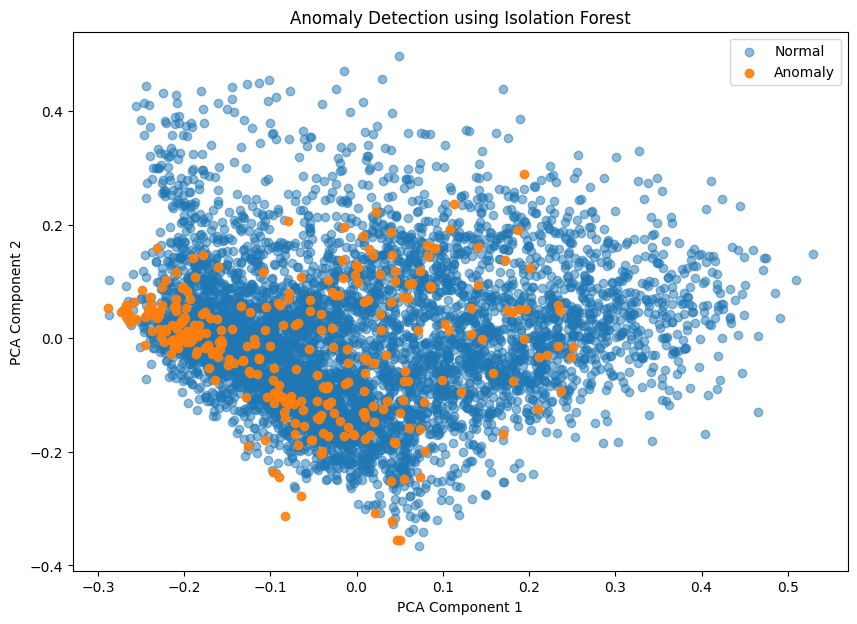

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

normal = df["anomaly"] == 1
anomaly = df["anomaly"] == -1

plt.scatter(
    X_pca[normal, 0],
    X_pca[normal, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_pca[anomaly, 0],
    X_pca[anomaly, 1],
    alpha=0.9,
    label="Anomaly"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Anomaly Detection using Isolation Forest")
plt.legend()

plt.show()

In [32]:
print(
    df["anomaly_label"].value_counts()
)

anomaly_label
Normal     5700
Anomaly     300
Name: count, dtype: int64


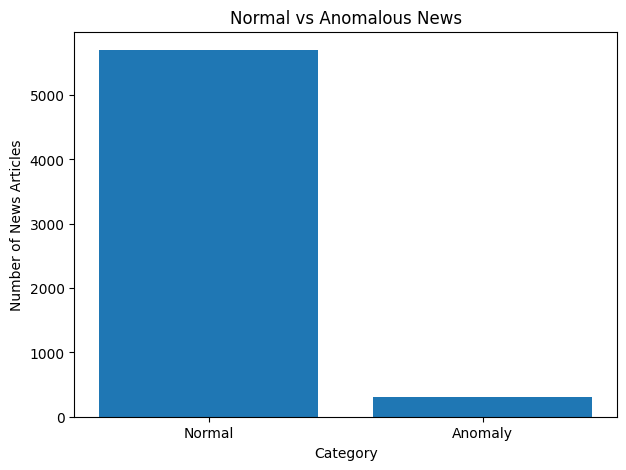

In [33]:
counts = df["anomaly_label"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    counts.index,
    counts.values
)

plt.xlabel("Category")
plt.ylabel("Number of News Articles")
plt.title("Normal vs Anomalous News")

plt.show()

In [ ]:
# ==========================================================
# ASSOCIATION RULE MINING + ANOMALY DETECTION
# NEWS DATASET
# ==========================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------

df = pd.read_csv("Data/news_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ----------------------------------------------------------
# 2. COMBINE TEXT
# ----------------------------------------------------------

df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("") + " " +
    df["subject"].fillna("")
)

# ----------------------------------------------------------
# 3. TEXT PREPROCESSING
# ----------------------------------------------------------

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    text = text.lower()

    words = re.findall(
        r"\b[a-z]{3,}\b",
        text
    )

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return words


df["tokens"] = df["combined_text"].apply(
    preprocess_text
)

# ----------------------------------------------------------
# 4. CREATE TRANSACTIONS
# ----------------------------------------------------------

transactions = df["tokens"].tolist()

# ----------------------------------------------------------
# 5. WORD FREQUENCY
# ----------------------------------------------------------

from collections import Counter

word_counts = Counter(
    word
    for transaction in transactions
    for word in set(transaction)
)

print("\nMost Common Words:")
print(word_counts.most_common(20))

# ----------------------------------------------------------
# 6. FILTER WORDS
# ----------------------------------------------------------

min_word_frequency = 20

frequent_words = {
    word
    for word, count in word_counts.items()
    if count >= min_word_frequency
}

filtered_transactions = [
    [
        word
        for word in transaction
        if word in frequent_words
    ]
    for transaction in transactions
]

filtered_transactions = [
    transaction
    for transaction in filtered_transactions
    if len(transaction) > 0
]

# ----------------------------------------------------------
# 7. TRANSACTION ENCODING
# ----------------------------------------------------------

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

transaction_array = te.fit(
    filtered_transactions
).transform(filtered_transactions)

transaction_df = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

print("\nTransaction Matrix:")
print(transaction_df.shape)

# ==========================================================
# 8. APRIORI
# ==========================================================

from mlxtend.frequent_patterns import apriori

frequent_itemsets_apriori = apriori(
    transaction_df,
    min_support=0.03,
    use_colnames=True
)

frequent_itemsets_apriori["length"] = (
    frequent_itemsets_apriori["itemsets"]
    .apply(len)
)

print("\nAPRiori Frequent Itemsets:")
print(
    frequent_itemsets_apriori
    .sort_values(
        "support",
        ascending=False
    )
    .head(20)
)

# ----------------------------------------------------------
# 9. APRIORI RULES
# ----------------------------------------------------------

from mlxtend.frequent_patterns import association_rules

rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric="confidence",
    min_threshold=0.5
)

rules_apriori = rules_apriori.sort_values(
    "lift",
    ascending=False
)

print("\nApriori Rules:")

print(
    rules_apriori[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

# ==========================================================
# 10. FP-GROWTH
# ==========================================================

from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets_fp = fpgrowth(
    transaction_df,
    min_support=0.03,
    use_colnames=True
)

frequent_itemsets_fp["length"] = (
    frequent_itemsets_fp["itemsets"]
    .apply(len)
)

print("\nFP-Growth Frequent Itemsets:")

print(
    frequent_itemsets_fp
    .sort_values(
        "support",
        ascending=False
    )
    .head(20)
)

# ----------------------------------------------------------
# 11. FP-GROWTH RULES
# ----------------------------------------------------------

rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.5
)

rules_fp = rules_fp.sort_values(
    "lift",
    ascending=False
)

print("\nFP-Growth Rules:")

print(
    rules_fp[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

# ==========================================================
# 12. TF-IDF
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    min_df=2,
    max_df=0.95
)

X_tfidf = vectorizer.fit_transform(
    df["combined_text"]
)

print("\nTF-IDF Shape:", X_tfidf.shape)

# ==========================================================
# 13. PCA
# ==========================================================

from sklearn.decomposition import PCA

X_dense = X_tfidf.toarray()

pca = PCA(
    n_components=50,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)

print("PCA Shape:", X_pca.shape)

# ==========================================================
# 14. ISOLATION FOREST
# ==========================================================

from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

predictions = iso_forest.fit_predict(
    X_pca
)

df["anomaly"] = predictions

# ----------------------------------------------------------
# 15. ANOMALY LABEL
# ----------------------------------------------------------

df["anomaly_label"] = df["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

# ----------------------------------------------------------
# 16. ANOMALY SCORE
# ----------------------------------------------------------

df["anomaly_score"] = (
    iso_forest.decision_function(X_pca)
)

# ----------------------------------------------------------
# 17. RESULTS
# ----------------------------------------------------------

print("\nAnomaly Distribution:")

print(
    df["anomaly_label"].value_counts()
)

# ----------------------------------------------------------
# 18. MOST ANOMALOUS ARTICLES
# ----------------------------------------------------------

most_anomalous = df.sort_values(
    "anomaly_score",
    ascending=True
)

print("\nMost Anomalous News:")

print(
    most_anomalous[
        [
            "title",
            "subject",
            "label",
            "anomaly_score",
            "anomaly_label"
        ]
    ].head(20)
)

# ==========================================================
# 19. VISUALIZATION
# ==========================================================

normal = df["anomaly"] == 1
anomaly = df["anomaly"] == -1

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[normal, 0],
    X_pca[normal, 1],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    X_pca[anomaly, 0],
    X_pca[anomaly, 1],
    alpha=0.9,
    label="Anomaly"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "News Anomaly Detection using Isolation Forest"
)

plt.legend()

plt.show()

Dataset Shape: (6000, 5)
                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  

Most Common Words:
[('sa